In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("AI_Job_Layoffs_Cleaned.csv")

In [3]:
numerical_columns = [
    'headcount_cut',
    'pct_workforce_cut',
    'ai_exposure_score',
    'revenue_growth_yoy_pct',
    'ai_capex_change_yoy_pct',
    'stock_price_change_30d_pct'
]

In [4]:
df[numerical_columns].describe()

,headcount_cut,pct_workforce_cut,ai_exposure_score,revenue_growth_yoy_pct,ai_capex_change_yoy_pct,stock_price_change_30d_pct
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000
mean,2457.245926,6.980274,53.366667,7.986148,20.458741,-0.445556
std,5202.597470,4.837882,21.230904,15.206205,23.232045,8.021726
min,5.000000,0.500000,2.000000,-46.900000,-20.000000,-23.400000
25%,31.000000,3.482500,39.000000,-2.400000,3.975000,-6.000000
50%,231.000000,5.755000,51.000000,8.250000,19.150000,-0.500000
75%,1703.000000,9.357500,67.000000,18.800000,36.375000,4.675000
max,52864.000000,34.050000,99.000000,52.400000,93.000000,30.000000


In [5]:
print(df[numerical_columns].mean())

headcount_cut                 2457.245926
pct_workforce_cut                6.980274
ai_exposure_score               53.366667
revenue_growth_yoy_pct           7.986148
ai_capex_change_yoy_pct         20.458741
stock_price_change_30d_pct      -0.445556
dtype: float64


In [6]:
print(df[numerical_columns].median())

headcount_cut                 231.000
pct_workforce_cut               5.755
ai_exposure_score              51.000
revenue_growth_yoy_pct          8.250
ai_capex_change_yoy_pct        19.150
stock_price_change_30d_pct     -0.500
dtype: float64


In [7]:
print(df[numerical_columns].mode())

   headcount_cut  pct_workforce_cut  ai_exposure_score  \
0            5.0                0.5               48.0   
1            NaN                NaN                NaN   

   revenue_growth_yoy_pct  ai_capex_change_yoy_pct  stock_price_change_30d_pct  
0                    14.2                    -20.0                        -6.4  
1                     NaN                      NaN                        -0.1  


In [8]:
print(df[numerical_columns].var())

headcount_cut                 2.706702e+07
pct_workforce_cut             2.340510e+01
ai_exposure_score             4.507513e+02
revenue_growth_yoy_pct        2.312287e+02
ai_capex_change_yoy_pct       5.397279e+02
stock_price_change_30d_pct    6.434809e+01
dtype: float64


In [9]:
print(df[numerical_columns].std())

headcount_cut                 5202.597470
pct_workforce_cut                4.837882
ai_exposure_score               21.230904
revenue_growth_yoy_pct          15.206205
ai_capex_change_yoy_pct         23.232045
stock_price_change_30d_pct       8.021726
dtype: float64


In [10]:
print(df[numerical_columns].skew())

headcount_cut                 3.481360
pct_workforce_cut             1.323670
ai_exposure_score             0.256815
revenue_growth_yoy_pct       -0.190751
ai_capex_change_yoy_pct       0.254341
stock_price_change_30d_pct    0.169272
dtype: float64


In [11]:
print(df[numerical_columns].kurt())

headcount_cut                 16.632953
pct_workforce_cut              2.342445
ai_exposure_score             -0.368783
revenue_growth_yoy_pct        -0.016327
ai_capex_change_yoy_pct       -0.430388
stock_price_change_30d_pct     0.156132
dtype: float64


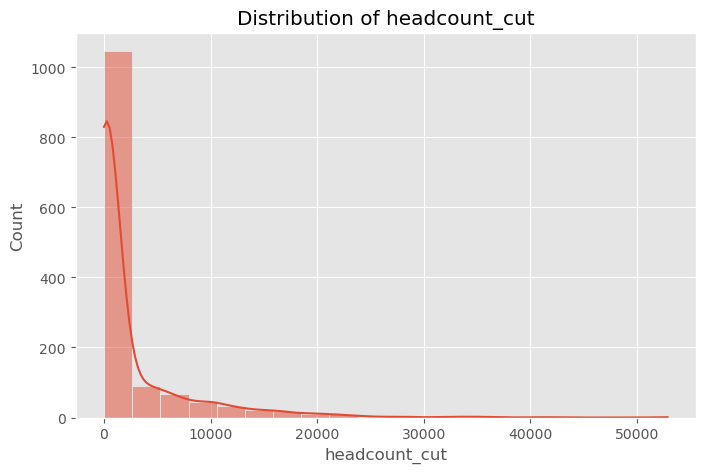

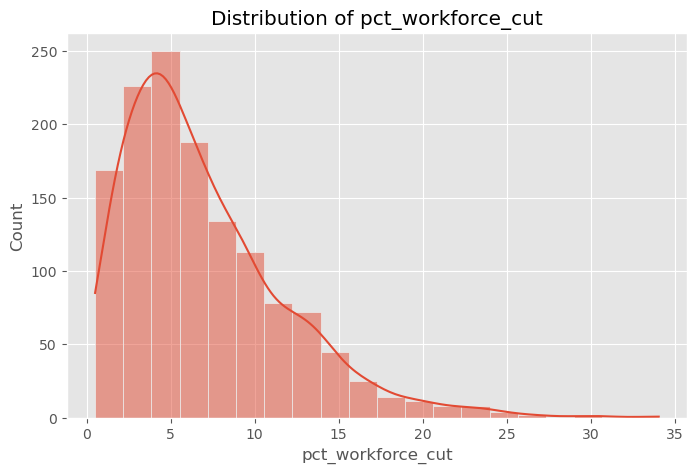

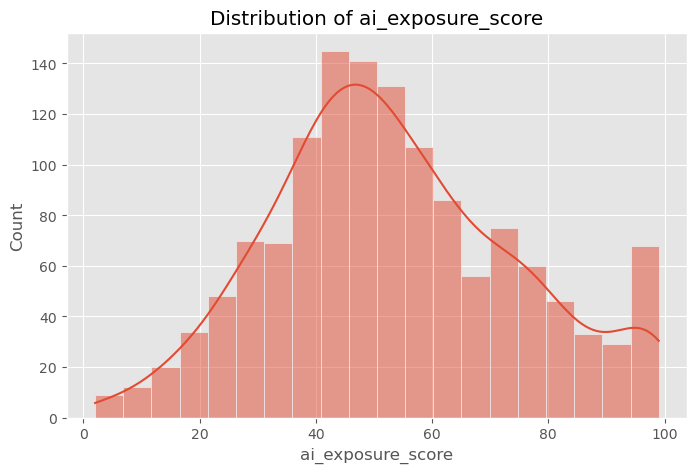

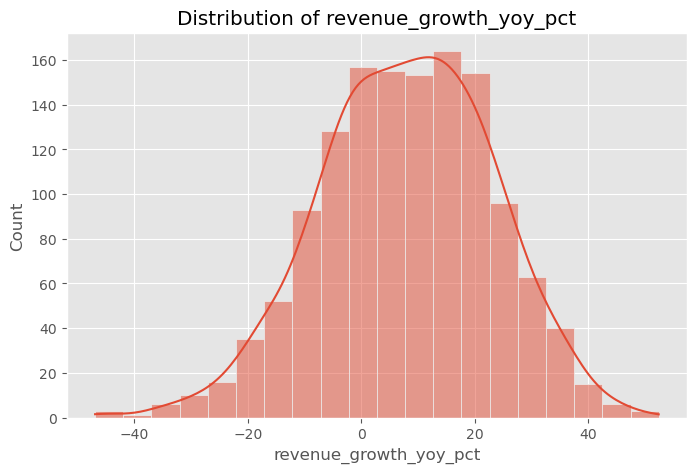

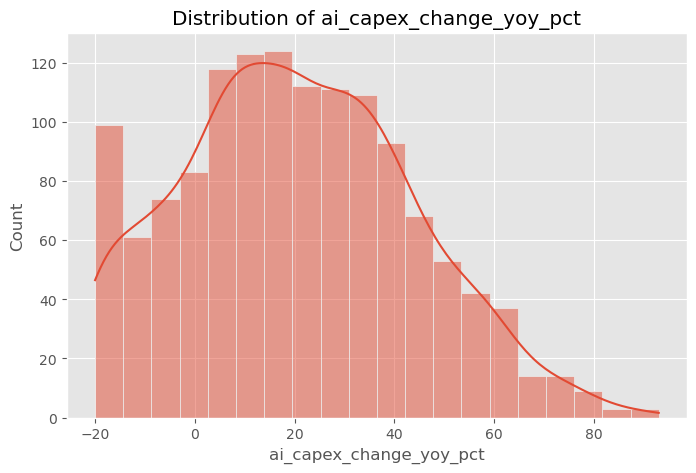

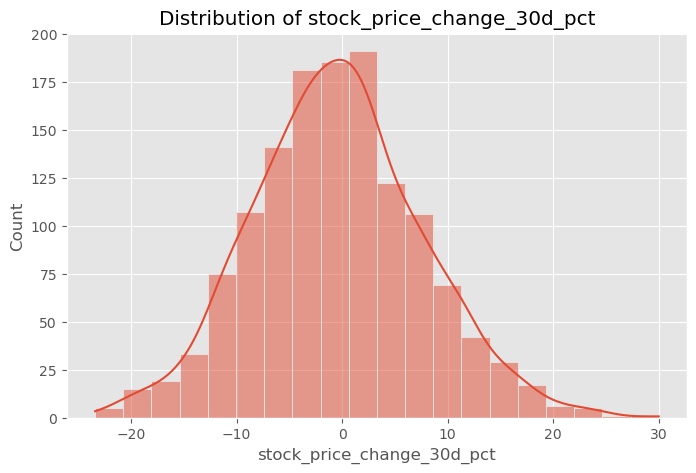

In [12]:
for col in numerical_columns:

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], bins=20, kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

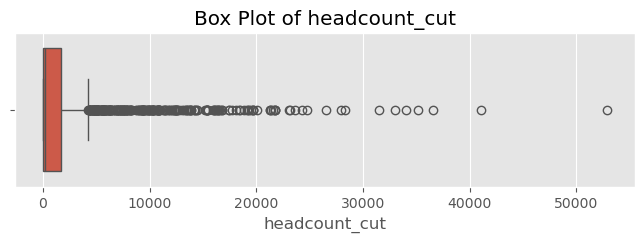

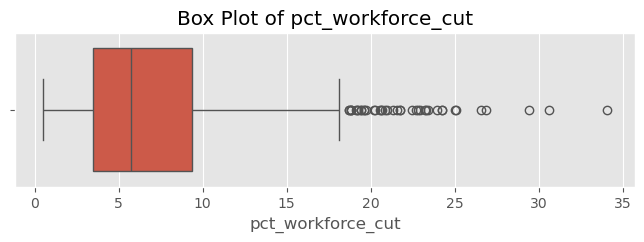

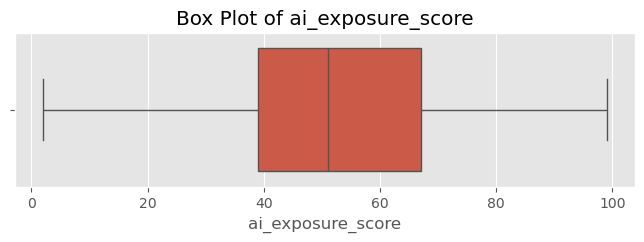

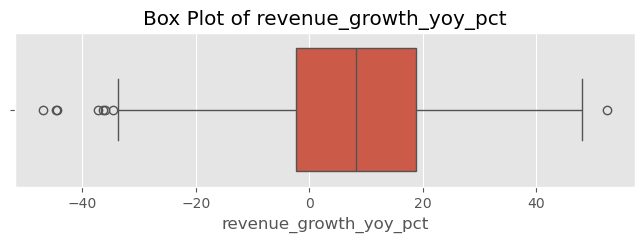

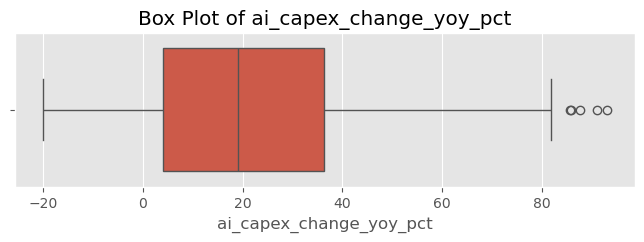

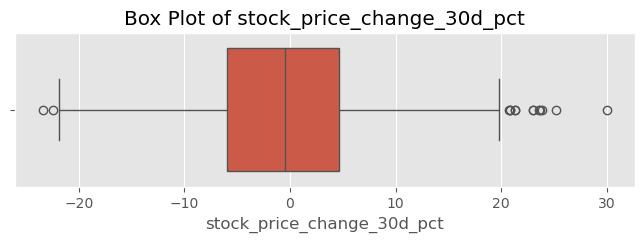

In [13]:
for col in numerical_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(f"Box Plot of {col}")

    plt.show()

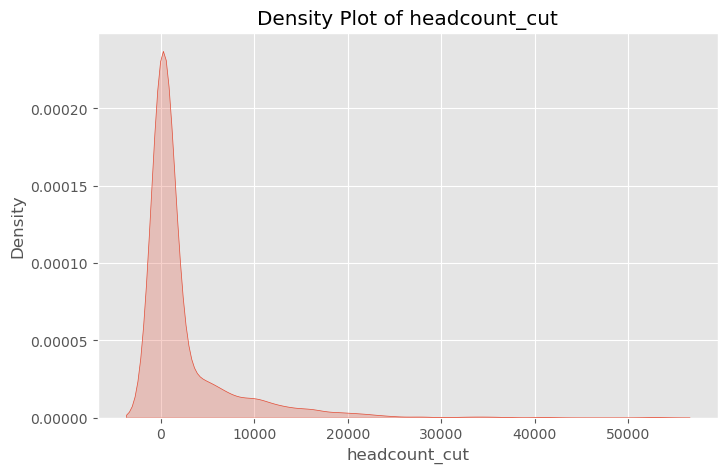

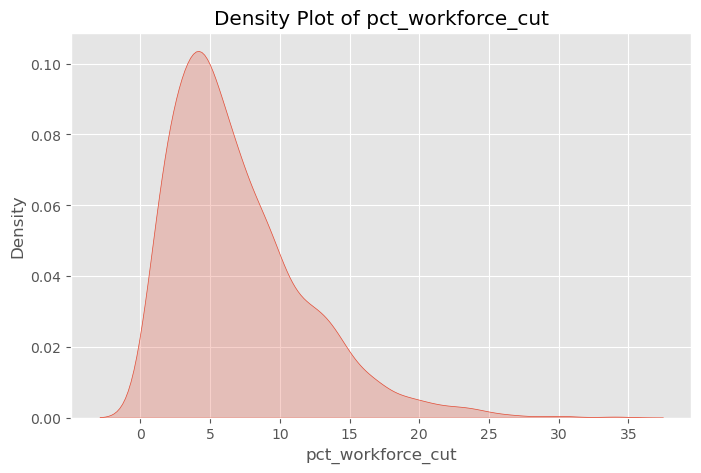

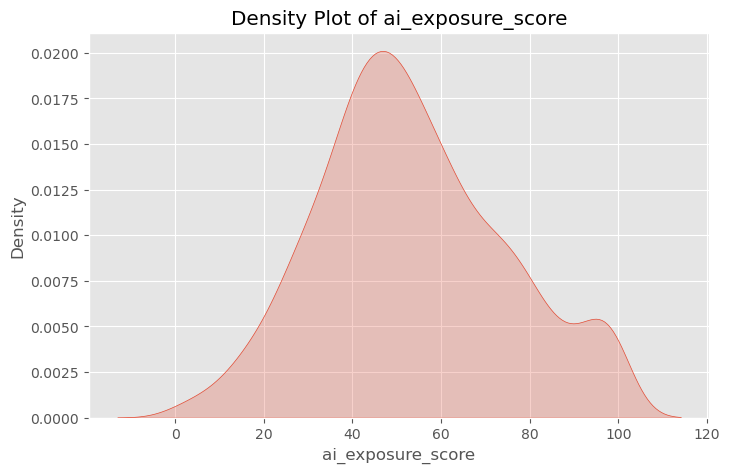

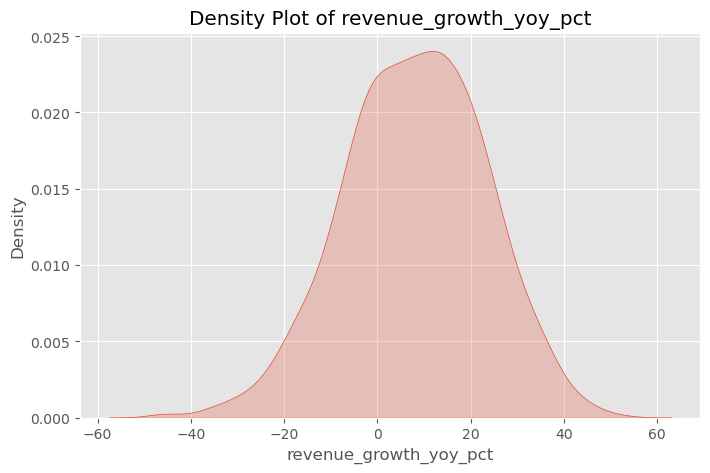

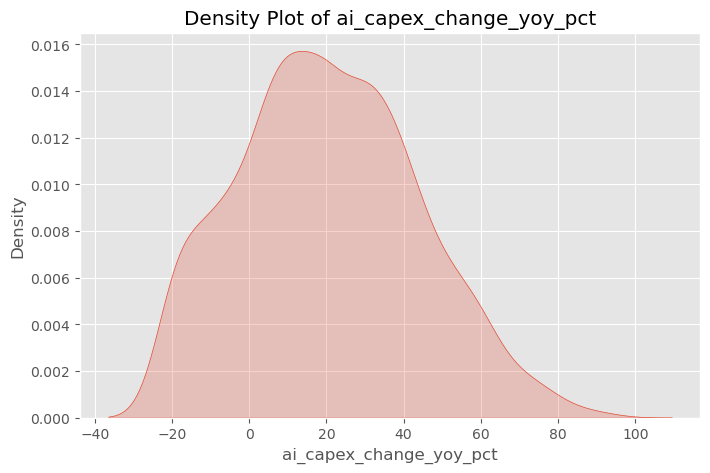

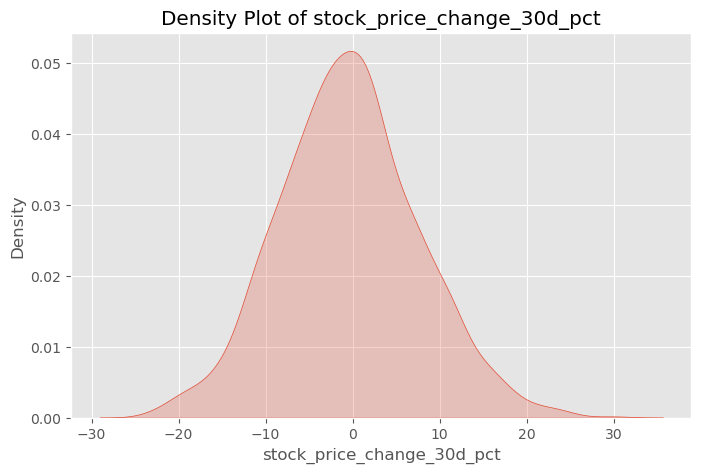

In [14]:
for col in numerical_columns:

    plt.figure(figsize=(8,5))

    sns.kdeplot(df[col], fill=True)

    plt.title(f"Density Plot of {col}")

    plt.show()

In [15]:
df[numerical_columns].quantile([0.25,0.50,0.75])

,headcount_cut,pct_workforce_cut,ai_exposure_score,revenue_growth_yoy_pct,ai_capex_change_yoy_pct,stock_price_change_30d_pct
0.25,31.0,3.4825,39.0,-2.40,3.975,-6.000
0.50,231.0,5.7550,51.0,8.25,19.150,-0.500
0.75,1703.0,9.3575,67.0,18.80,36.375,4.675


In [16]:
Q1 = df[numerical_columns].quantile(0.25)

Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

headcount_cut                 1672.000
pct_workforce_cut                5.875
ai_exposure_score               28.000
revenue_growth_yoy_pct          21.200
ai_capex_change_yoy_pct         32.400
stock_price_change_30d_pct      10.675
dtype: float64


In [17]:
lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = ((df[numerical_columns] < lower) |
            (df[numerical_columns] > upper))

print(outliers.sum())

headcount_cut                 249
pct_workforce_cut              41
ai_exposure_score               0
revenue_growth_yoy_pct          8
ai_capex_change_yoy_pct         5
stock_price_change_30d_pct     14
dtype: int64


In [18]:
corr = df[numerical_columns].corr()

corr

,headcount_cut,pct_workforce_cut,ai_exposure_score,revenue_growth_yoy_pct,ai_capex_change_yoy_pct,stock_price_change_30d_pct
headcount_cut,1.000000,0.322375,0.015960,0.020525,0.053938,0.021157
pct_workforce_cut,0.322375,1.000000,0.002838,0.000275,0.002333,-0.016078
ai_exposure_score,0.015960,0.002838,1.000000,0.032322,0.102766,0.081893
revenue_growth_yoy_pct,0.020525,0.000275,0.032322,1.000000,0.216737,0.078188
ai_capex_change_yoy_pct,0.053938,0.002333,0.102766,0.216737,1.000000,0.120978
stock_price_change_30d_pct,0.021157,-0.016078,0.081893,0.078188,0.120978,1.000000


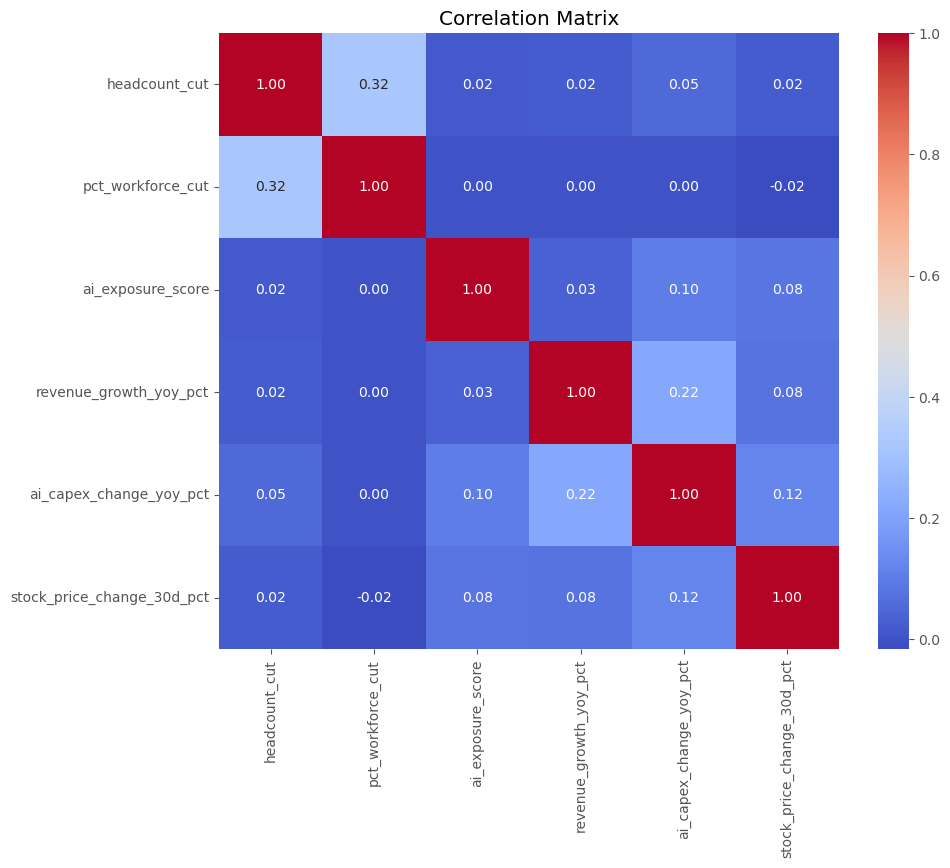

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

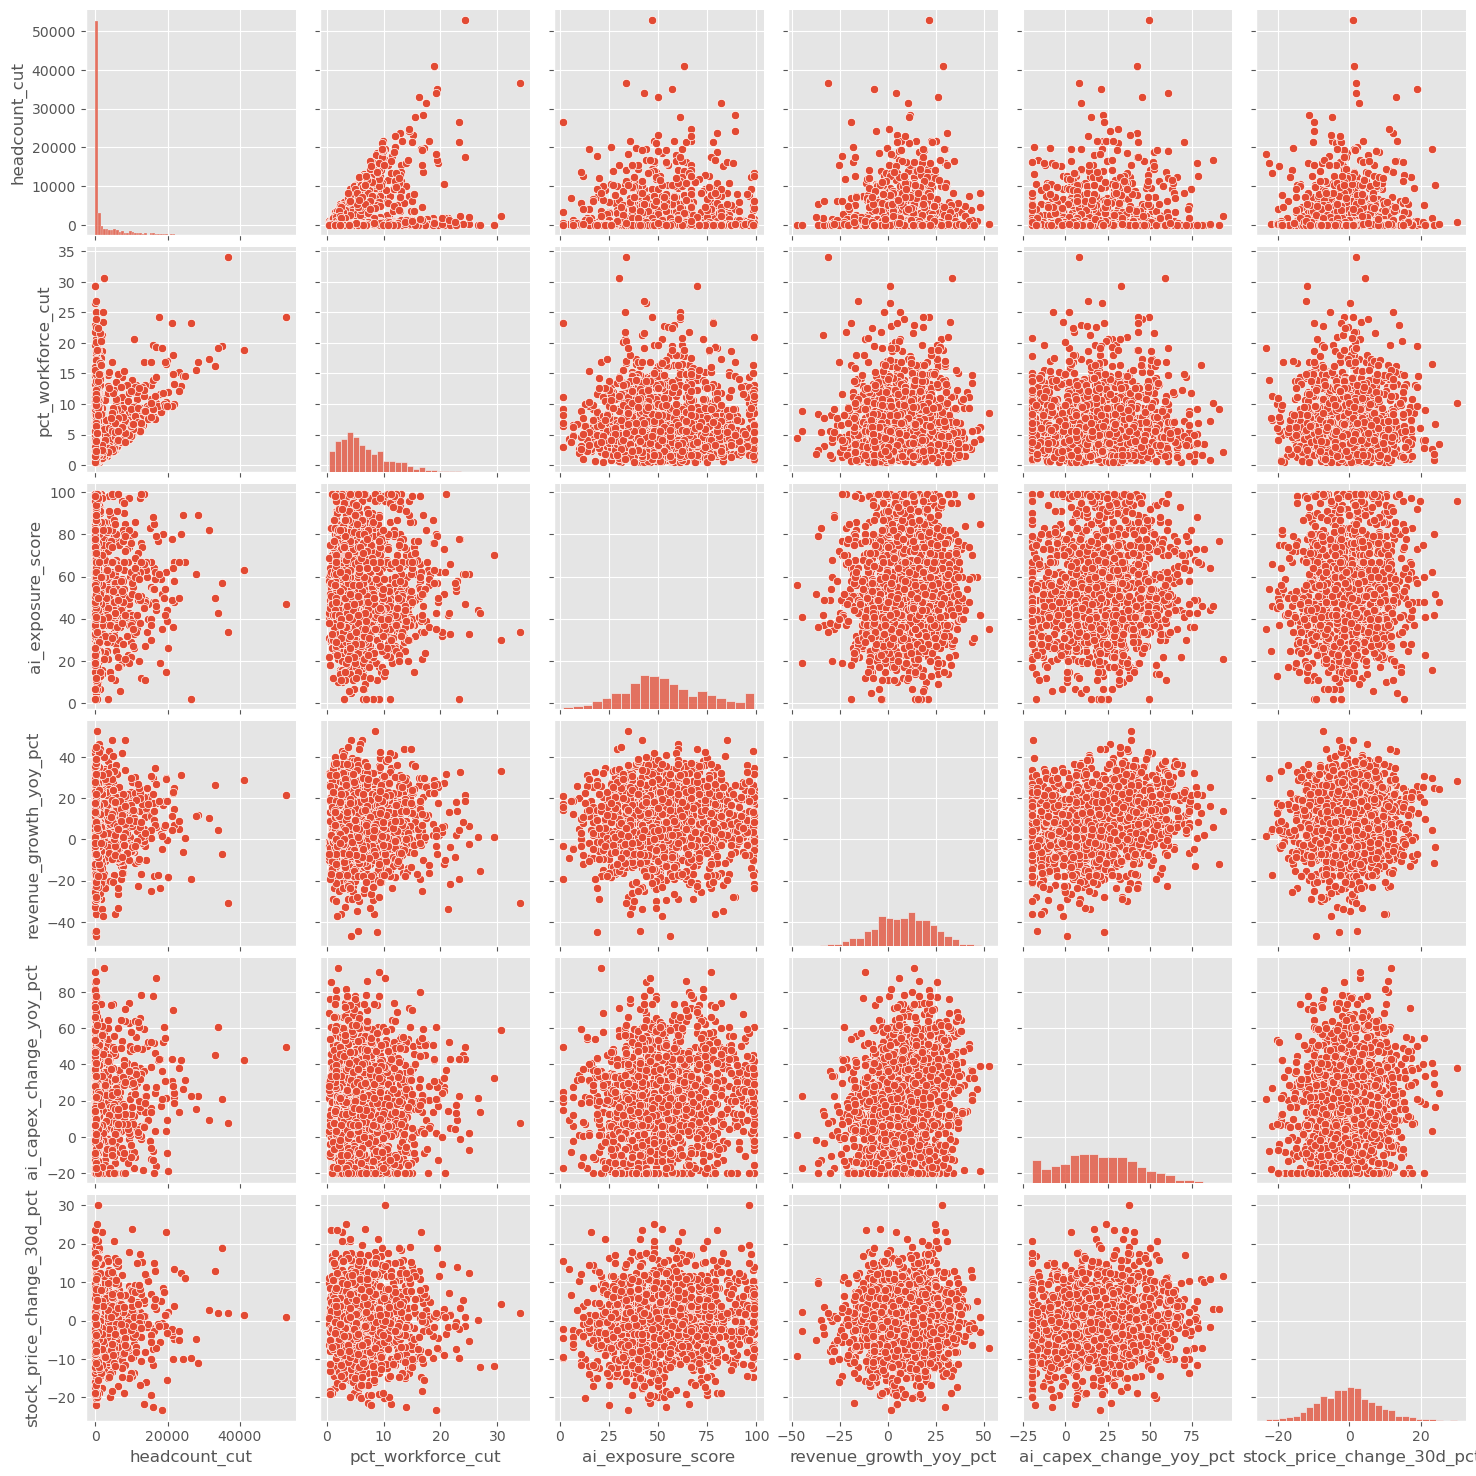

In [20]:
sns.pairplot(df[numerical_columns])

plt.show()

In [21]:
df[numerical_columns].cov()

,headcount_cut,pct_workforce_cut,ai_exposure_score,revenue_growth_yoy_pct,ai_capex_change_yoy_pct,stock_price_change_30d_pct
headcount_cut,2.706702e+07,8114.038146,1762.889745,1623.761971,6519.346107,882.962286
pct_workforce_cut,8.114038e+03,23.405099,0.291449,0.020200,0.262222,-0.623939
ai_exposure_score,1.762890e+03,0.291449,450.751297,10.434734,50.688083,13.947109
revenue_growth_yoy_pct,1.623762e+03,0.020200,10.434734,231.228681,76.567078,9.537315
ai_capex_change_yoy_pct,6.519346e+03,0.262222,50.688083,76.567078,539.727896,22.545510
stock_price_change_30d_pct,8.829623e+02,-0.623939,13.947109,9.537315,22.545510,64.348086


In [22]:
summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Variance": df[numerical_columns].var(),
    "Std Dev": df[numerical_columns].std(),
    "Skewness": df[numerical_columns].skew(),
    "Kurtosis": df[numerical_columns].kurt()
})

summary

,Mean,Median,Mode,Variance,Std Dev,Skewness,Kurtosis
headcount_cut,2457.245926,231.000,5.0,2.706702e+07,5202.597470,3.481360,16.632953
pct_workforce_cut,6.980274,5.755,0.5,2.340510e+01,4.837882,1.323670,2.342445
ai_exposure_score,53.366667,51.000,48.0,4.507513e+02,21.230904,0.256815,-0.368783
revenue_growth_yoy_pct,7.986148,8.250,14.2,2.312287e+02,15.206205,-0.190751,-0.016327
ai_capex_change_yoy_pct,20.458741,19.150,-20.0,5.397279e+02,23.232045,0.254341,-0.430388
stock_price_change_30d_pct,-0.445556,-0.500,-6.4,6.434809e+01,8.021726,0.169272,0.156132
